# AutoGluon.TimeSeries V1.4 Cheatsheet

This notebook contains the key code snippets from the AutoGluon Time Series cheatsheet.

In [ ]:
import pandas as pd

In [ ]:
data_dir = os.path.join(os.getcwd(), 'data')

generacion = pd.read_csv(os.path.join(data_dir,'generacion.csv'))
generacion['timestamp'] = pd.to_datetime(generacion['timestamp'])

In [88]:
generacion.columns

Index(['Codigo Central', 'timestamp', 'Generacion_MWh'], dtype='object')

In [89]:
grouped_generacion=generacion.groupby("Codigo Central")

In [90]:
grouped_generacion.count()

,timestamp,Generacion_MWh
Codigo Central,,
Canela,8377,8377
Canela 2,8377,8377
El Arrayán,4992,4992
EÓLICA VALLE DE LOS VIENTOS_Eólico,7272,7272
Eólica Los Cururos,4488,4488
Eólica Negrete,3576,3576
Eólica Taltal,1728,1728
Eólica Totoral,8377,8377
HUAYCA1,7295,7295


In [91]:
min_date=generacion['timestamp'].min()
max_date=generacion['timestamp'].max()

In [92]:
min_date,max_date

(Timestamp('2014-01-01 00:00:00'), Timestamp('2014-12-31 23:00:00'))

In [93]:
full_date_range = pd.date_range(start=min_date, end=max_date, freq='h')

In [94]:
len(full_date_range)

8760

In [95]:
reindexed_dfs = []
for station,df in grouped_generacion:
    df.set_index('timestamp',inplace=True)
    df=df[~df.index.duplicated(keep='first')]
    df_reindexed = df.reindex(full_date_range)
    df_reindexed['Codigo Central']=df_reindexed['Codigo Central'].bfill()
    df_reindexed['Codigo Central']=df_reindexed['Codigo Central'].ffill()
    df_reindexed['Generacion_MWh']=df_reindexed['Generacion_MWh'].bfill()    
    df_reindexed['Generacion_MWh']=df_reindexed['Generacion_MWh'].interpolate()    
    reindexed_dfs.append(df_reindexed)
    
    #df_reindexed = df.reindex(full_date_range)

In [96]:
generacion_reindexed=pd.concat(reindexed_dfs)

In [97]:
generacion_reindexed.groupby('Codigo Central').count()

,Generacion_MWh
Codigo Central,
Canela,8760
Canela 2,8760
El Arrayán,8760
EÓLICA VALLE DE LOS VIENTOS_Eólico,8760
Eólica Los Cururos,8760
Eólica Negrete,8760
Eólica Taltal,8760
Eólica Totoral,8760
HUAYCA1,8760


In [98]:
generacion_reindexed.reset_index(names='timestamp',inplace=True)

In [99]:
generacion_reindexed

,timestamp,Codigo Central,Generacion_MWh
0,2014-01-01 00:00:00,Canela,4.30
1,2014-01-01 01:00:00,Canela,2.30
2,2014-01-01 02:00:00,Canela,2.40
3,2014-01-01 03:00:00,Canela,1.60
4,2014-01-01 04:00:00,Canela,1.50
...,...,...,...
315355,2014-12-31 19:00:00,Ucuquer 2,0.94
315356,2014-12-31 20:00:00,Ucuquer 2,0.94
315357,2014-12-31 21:00:00,Ucuquer 2,0.94
315358,2014-12-31 22:00:00,Ucuquer 2,0.94


### Convert Raw Data into a TimeSeriesDataFrame

Convert your raw data into the format required by AutoGluon: `TimeSeriesDataFrame`.

In [ ]:
def train_test_split(data,split_fraction,feature_keys):
    data=data[feature_keys]
    train_split = int(split_fraction * int(data.shape[0]))
    data=data._get_numeric_data()
    data_mean = data[:train_split].mean(axis=0)
    data_std = data[:train_split].std(axis=0)
    # Handle zero standard deviation to avoid division by zero
    data_std[data_std == 0] = 1e-9 # Replace zero with a small number to avoid division by zero

    data = (data - data_mean) / data_std
    train_data = data.iloc[0 : train_split].fillna(data_mean)
    val_data = data.iloc[train_split:].fillna(data_mean) # Changed slicing to include train_split for correct split
    return train_data,val_data


def create_batch(data,lag,future):
    df_lag=pd.concat([data[:-future].shift(i) for i in range(lag-1,-1,-1)],axis=1).dropna()
    #df_lag.columns=['pm_'+str(i) for i in range(lag,-1,1)]
    X=df_lag.values
    y=data[future+lag-1:].values
    return X,y

def create_batch_multistep(df,lag,future,feature=None):
    if feature is None:
        data=df
    else:
        data=df[feature]

    X = []
    y = []
    for i in range(len(data) - lag - future + 1):
        X.append(data.iloc[i : i + lag].values)
        y.append(data.iloc[i + lag : i + lag + future].values)

    X = np.array(X)
    y = np.array(y)
    return X,y

In [101]:
import numpy as np 

split_fraction = 0.8
feature_keys = ['Generacion_MWh']
X_train_datasets=list()
y_train_datasets=list()
X_test_datasets=list()
y_test_datasets=list()
future=24
past=2*24

dataset_names=list()
for item_id, gdf in generacion_reindexed.groupby('Codigo Central'):
    train,test=train_test_split(gdf,split_fraction,feature_keys)
    train_multi_feature=list()
    test_multi_feature=list()
    for feature in train.columns:
        X_train,y_train=create_batch_multistep(train,past,future,feature)
        X_test,y_test=create_batch_multistep(test,past,future,feature)
        train_multi_feature.append(X_train)
        test_multi_feature.append(X_test)
        if feature=='Generacion_MWh':
            y_train_datasets.append(y_train)
            y_test_datasets.append(y_test)
    X_train_datasets.append(np.stack(train_multi_feature,axis=-1))
    X_test_datasets.append(np.stack(test_multi_feature,axis=-1))
    dataset_names.append(item_id)
X_train_datasets=np.stack(X_train_datasets,axis=0)
y_train_datasets=np.stack(y_train_datasets,axis=0)
X_test_datasets=np.stack(X_test_datasets,axis=0)
y_test_datasets=np.stack(y_test_datasets,axis=0)

In [102]:
X_train_datasets.shape,X_test_datasets.shape

((36, 6936, 48, 1), (36, 1681, 48, 1))

In [103]:
y_train_datasets.shape

(36, 6936, 24)

In [177]:
np.sum(np.isinf(y_test_datasets))

np.int64(57241)

# Train Global Model

In [131]:
import torch
import torch.nn as nn
from torch.autograd import Variable

class LSTMForecast(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers=2, dropout=0.2):
        super(LSTMForecast, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=dropout)
        self.fc_mean = nn.Linear(num_layers*hidden_size, output_size)
        self.fc_var = nn.Linear(num_layers*hidden_size, output_size)
        self.softplus = nn.Softplus(beta=1.0, threshold=20.0)
        self.num_layers = num_layers
        self.hidden_size = hidden_size
        
    def forward(self, x):
        device = x.device # Get the device from the input tensor
        h_0 = Variable(torch.zeros(
            self.num_layers, x.size(0), self.hidden_size)).to(device) # Move h_0 to the correct device

        c_0 = Variable(torch.zeros(
            self.num_layers, x.size(0), self.hidden_size)).to(device)
        
        # Propagate input through LSTM
        ula, (h_out, _) = self.lstm(x, (h_0, c_0))
        
        h_out = h_out.view(-1, self.hidden_size*self.num_layers)      
        mean = self.fc_mean(h_out)  # Take output from the last LSTM cell
        var = self.softplus(self.fc_var(h_out)) 
        return mean,var

In [132]:
X_train_datasets.shape,y_train_datasets.shape

((36, 6936, 48, 1), (36, 6936, 24))

In [133]:
X_train_global=X_train_datasets.reshape(X_train_datasets.shape[0]*X_train_datasets.shape[1],X_train_datasets.shape[2],1)
X_test_global=X_test_datasets.reshape(X_test_datasets.shape[0]*X_test_datasets.shape[1],X_test_datasets.shape[2],1)
y_train_global=y_train_datasets.reshape(y_train_datasets.shape[0]*y_train_datasets.shape[1],y_train_datasets.shape[2])
y_test_global=y_test_datasets.reshape(y_test_datasets.shape[0]*y_test_datasets.shape[1],y_test_datasets.shape[2])

In [134]:
X_train_global.shape,y_train_global.shape

((249696, 48, 1), (249696, 24))

In [175]:
np.sum(np.isinf(y_train_global))

np.int64(0)

In [176]:
np.sum(np.isinf(y_test_global))

np.int64(57241)

In [135]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using MPS device for acceleration.")
else:
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    print("MPS device not available, falling back to CPU.")


print(f"Using device: {device}")

MPS device not available, falling back to CPU.
Using device: cuda


In [136]:
def get_dataloader(X,y,batch_size,axis=0,device='cpu',permute=True):
    num_train=X.shape[axis]
    indices = np.array(list(range(0,num_train)))
    if permute:
        indices=np.random.permutation(indices)
    for i in range(0, len(indices),batch_size):
        batch_indices = indices[i: i+batch_size]
        X_batch=torch.from_numpy(X[batch_indices,:,:].astype(np.float32)).to(device)
        y_batch=torch.from_numpy(y[batch_indices,:].astype(np.float32)).to(device)
        yield X_batch,y_batch 
              

In [183]:
from torch import optim 

model=LSTMForecast(input_size=1,hidden_size=32,output_size=24,num_layers=1).to(device)
loss_fn = nn.GaussianNLLLoss()
test_loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

/home/sergio/code/automl_data_science/.venv/lib/python3.12/site-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  warnings.warn(


In [ ]:
n_epochs = 100
batch_size=128
loss_history=list()
for epoch in range(n_epochs):
    model.train()
    for X_batch, y_batch in get_dataloader(X_train_global,y_train_global,batch_size,0,device):
        y_pred,y_var = model(X_batch)
        loss = loss_fn(y_batch, y_pred,y_var)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    # Validation
    loss_history.append(loss.item())


Epoch 0: train RMSE -0.9231, test RMSE inf
Epoch 10: train RMSE -0.9932, test RMSE inf
Epoch 20: train RMSE -1.0558, test RMSE inf
Epoch 30: train RMSE -1.0724, test RMSE inf
Epoch 40: train RMSE -1.1319, test RMSE inf
Epoch 50: train RMSE -1.0464, test RMSE inf
Epoch 60: train RMSE -1.0471, test RMSE inf
Epoch 70: train RMSE -0.9737, test RMSE inf
Epoch 80: train RMSE -1.3475, test RMSE inf
Epoch 90: train RMSE -1.4011, test RMSE inf


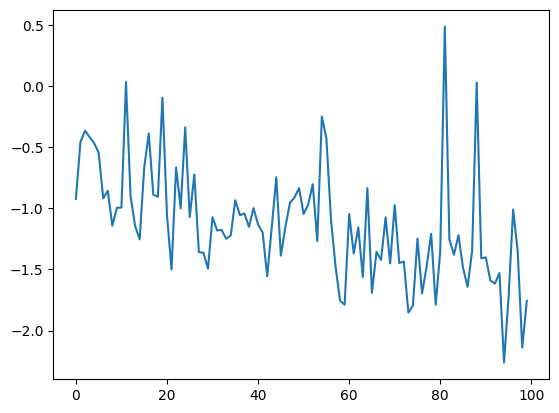

In [178]:
import matplotlib.pyplot as plt

plt.plot(loss_history)

In [193]:
y_test_mean=list()
y_test_var=list()
test_loss=0.0
model.eval()
with torch.no_grad():
    for X_batch_test, y_batch_test in get_dataloader(X_test_global,y_test_global,batch_size,0,device):
        y_pred,y_var = model(X_batch_test)
        y_test_mean.append(y_pred)
        y_test_var.append(y_var)
        test_loss+= test_loss_fn(torch.nan_to_num(y_batch_test), y_pred).item()
    

In [206]:
from sklearn.metrics import r2_score

y_test_mean_np=np.concatenate([y.to('cpu').detach().numpy() for y in y_test_mean])

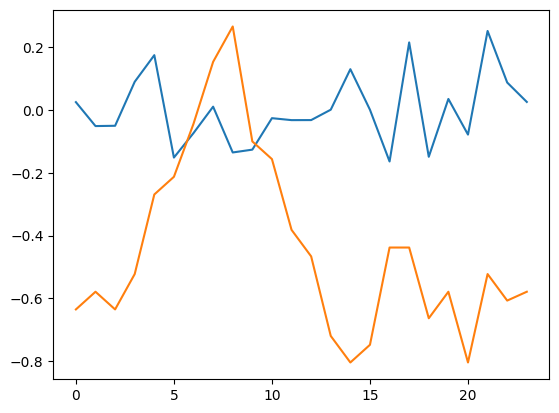

In [207]:
plt.plot(range(y_test_mean_np.shape[1]),y_test_mean_np[0,:])
plt.plot(range(y_test_global.shape[1]),y_test_global[0,:])

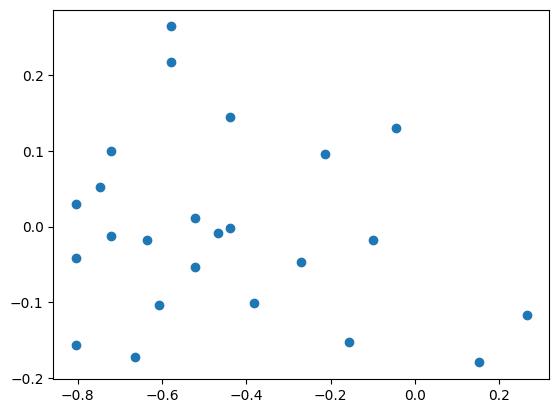

In [211]:
plt.scatter(y_test_global[2,:],y_test_mean_np[2,:])